Upload a face image:


Saving images (1).jpg to images (1) (2).jpg

Original BGR image:


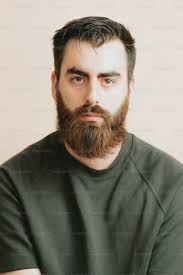


After BGR → RGB conversion:


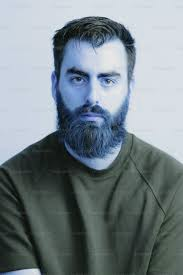


Found 1 face(s)
  Face 1 → confidence: 0.842

Final result with detection:


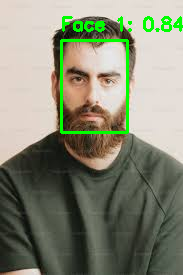

In [4]:
!pip install mtcnn lz4 -q

import cv2
from mtcnn import MTCNN
from google.colab.patches import cv2_imshow
from google.colab import files

# Upload your image
print("Upload a face image:")
uploaded = files.upload()
filename = list(uploaded.keys())[0]

# Load and show original BGR
img = cv2.imread(filename)
print("\nOriginal BGR image:")
cv2_imshow(img)

# Convert to RGB and show
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
print("\nAfter BGR → RGB conversion:")
cv2_imshow(img_rgb)

# Detect faces
detector = MTCNN()
faces = detector.detect_faces(img_rgb)
print(f"\nFound {len(faces)} face(s)")

# Draw boxes
img_draw = img.copy()

for i, face in enumerate(faces):
    x, y, w, h = face['box']
    conf = face['confidence']

    cv2.rectangle(img_draw, (x, y), (x+w, y+h), (0, 255, 0), 2)
    cv2.putText(img_draw, f"Face {i+1}: {conf:.2f}",
                (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

    print(f"  Face {i+1} → confidence: {conf:.3f}")

print("\nFinal result with detection:")
cv2_imshow(img_draw)